This notebook fits by-cre models on the shendure data & demonstrates that estimated nb parameters track closely with UMI means, as expected.

The matrix-creation and fitting code is independent of the main scMPRA package, since its this analysis that informed the package code.

# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#imports
import pandas as pd
import numpy as np
import time
import pickle
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

import tqdm

In [3]:
#create dask cluster
from dask.distributed import Client, LocalCluster
cluster=LocalCluster()
client = Client(cluster)

2025-07-11 17:09:17,174 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-70da_j7s', purging
2025-07-11 17:09:17,174 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-l133d2wh', purging
2025-07-11 17:09:17,175 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-0gu0yesi', purging
2025-07-11 17:09:17,175 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-hojfijys', purging
2025-07-11 17:09:17,175 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-687hr8wn', purging
2025-07-11 17:09:17,176 - distributed.diskutils - INFO - Found st

# Describe with an ortho

In [4]:
#load data
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_grouped.txt")
shendure.set_negative_controls(["minP","noP"])
shendure.set_reference_cell("Pluripotent")
shendure.ortho_filter()

scMPRAforge: INFO: Dropped 372 of 1833 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [5]:
#create
primordial=scm.ortho()
primordial.criss_cross(client=client,
                       dat=shendure)

Metal device set to: Metal device set to: Metal device set to: Metal device set to: Apple M4 ProMetal device set to: Apple M4 Pro
Apple M4 ProApple M4 Pro

Metal device set to: Apple M4 Pro

Apple M4 Pro
systemMemory: 24.00 GB


systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

maxCacheSize: 8.00 GB


systemMemory: 24.00 GB

systemMemory: 24.00 GB

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB


systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

maxCacheSize: 8.00 GB

maxCacheSize: 8.00 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB



In [ ]:
primordial.by_cre.model.flatten_futures()

{'Gata4_chr14_5710': <Future: finished, type: dict, key: _tensorzinb_fit-f1569d25e07925815de740fdefe57047>,
 'Klf4_chr4_3952': <Future: finished, type: dict, key: _tensorzinb_fit-3360d27f952ee0c58654f0e94859dd01>,
 'Lama1_chr17_7793': <Future: finished, type: dict, key: _tensorzinb_fit-b756910ee6f4682cbce73bcc29fe113d>,
 'Sox17_chr1_67': <Future: finished, type: dict, key: _tensorzinb_fit-36fff73741b3748ef9f4e73d8b2d63fc>,
 'Sox17_chr1_82': <Future: finished, type: dict, key: _tensorzinb_fit-5ff8e04c92c22cfd98ebed15bd3a0819>,
 'Sparc_chr11_7203': <Future: finished, type: dict, key: _tensorzinb_fit-ebf8b3034abd4f843d3e1a12d4d6c5c6>,
 'Sparc_chr11_7235': <Future: finished, type: dict, key: _tensorzinb_fit-613cbce4d2b02b34ec49152ce01dcc5d>,
 'reference': <Future: finished, type: dict, key: _tensorzinb_fit-315b3b9ae56c8ee4576ae09cdb022db4>,
 'Bend5_chr4_8170': <Future: finished, type: dict, key: _tensorzinb_fit-726c4263a27c5410c229963db9fb2be3>,
 'Bend5_chr4_8199': <Future: finished, type:

In [24]:
def _extract_parameters(level,split,model,design_matrix):
    #remove for submission
    model=model.result()
    design_matrix=design_matrix.result()

    ## Extract design matrix data ##
    X=design_matrix["nb_regressors"]
    y=design_matrix["regressand"]
    Z=design_matrix["zi_regressors"]
    reference=design_matrix["reference"]
    model_type=design_matrix["model_type"]

    ## theta ##
    theta=model['weights']['theta'].squeeze()
    
    ## Mu ##
    #multiply design matrix by weights
    linear_mu= X @ model["weights"]["x_mu"]
    #undo the link function to get predictions for each cell
    mu_predictions=np.exp(linear_mu)
    
    #Get the level names for each row in the DF
    level_type=scm.anti_split(split)

    if model_type=="contrastable":
        row_labeling=scm.undo_one_hot_encoding(X)
        row_labeling=row_labeling[f"{level_type}, contr.treatment(base='{reference}')"]
        row_labeling=row_labeling.str.removeprefix("T.")
    elif model_type=="simulation_only":
        #only one cell-type
        row_labeling=pd.Series(np.repeat(reference,len(mu_predictions)))
    #Merge those level names onto the predictions for each row
    mu_predictions_df=pd.DataFrame({level_type:row_labeling,'mu':mu_predictions.squeeze()})

    #aggregate predictions to one per level name
    mu_summary=mu_predictions_df.groupby(level_type).agg("mean")
    #nb[key]=mu_summary
    #print(mu_summary)

    ## ZI ##
    # multiply design matrix by weights
    linear_zi=(Z.to_numpy() @ model["weights"]["x_pi"])
    zi_predictions=linear_zi=1/(1+np.exp(-linear_zi))

    #extract names 
    replicate_labeling=scm.undo_one_hot_encoding(Z)["rep_id"]
    replicate_labeling=replicate_labeling.str.removeprefix("T.")
    #apply names to ZI
    zi_predictions_df=pd.DataFrame({'rep_id':replicate_labeling,'zi':zi_predictions.squeeze()})
    #aggregate
    zi_summary=zi_predictions_df.groupby("rep_id").agg("mean")
    
    #mu_summary, zi_summary, theta


split="cell_type"
for level in primordial.by_cell_type.model:
    print(level)

_extract_parameters(level="NeuroectodermBrain",
                    split=primordial.by_cell_type.split,
                    model=primordial.by_cell_type.model["NeuroectodermBrain"],
                    design_matrix=primordial.by_cell_type_design["NeuroectodermBrain"])

NeuroectodermBrain
EpiblastPrimitiveStreak
SurfaceEctoderm
Mesoderm
reference
Haematoendothelial
Cardiomyocytes
NeuroectodermRostral
ExEndodermParietal
ExEndodermVisceral


In [23]:
primordial.by_cell_type.split

'cell_type'

In [12]:
primordial.by_cre_parameters.result()

2025-07-11 16:12:50,913 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.53 GiB -- Worker memory limit: 3.43 GiB
2025-07-11 16:13:01,013 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.53 GiB -- Worker memory limit: 3.43 GiB
2025-07-11 16:13:11,113 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB



In [11]:
primordial.by_cell_type_parameters

<Future: pending, key: model_to_parameters-417c93a7ba15821c6e43b0833f5219f2>

In [11]:
try:
    result = primordial.by_cell_type_parameters.result()
except Exception as e:
    import traceback
    traceback.print_exc()  # or print(str(e))



Traceback (most recent call last):
  File "/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/ipykernel_34698/914060547.py", line 2, in <module>
    result = primordial.by_cell_type_parameters.result()
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/client.py", line 284, in result
    raise exc.with_traceback(tb)
  File "/Users/mcnoon/tabula-rasa/analyses/supporting/scMPRAforge/core.py", line 777, in model_to_parameters
    design_matrix[key]=design_matrix[key].result()
AttributeError: 'dict' object has no attribute 'result'


2025-07-11 16:02:36,742 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.61 GiB -- Worker memory limit: 3.43 GiB
2025-07-11 16:02:46,842 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.61 GiB -- Worker memory limit: 3.43 GiB
2025-07-11 16:02:56,842 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

In [ ]:
QC_cre=scm.nb_versus_means(params=cre_params,
                design_matricies=cre_mats,
                scMPRAdat=shendure)

QC_ct=scm.nb_versus_means(params=ct_params,
                design_matricies=ct_mats,
                scMPRAdat=shendure)

AttributeError: module 'scMPRAforge' has no attribute 'nb_versus_means'

# Examine QC metrics

TODO: check the one that failed.

Now that we've generated some QC metrics, let's examine them. First, let's look at the mu min & max : none should be below zero, none should be above 1000.

In [63]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(QC_cre)
print("ct")
minimax(QC_ct)

cre
min 0.005827537948835809, max 479.23520038370475
ct
min 0.0037516340813858002, max 445.75962275018054


All in the right ballpark!

Now let's look at the correlations.

---
low r Cdk5r1_chr11_12595
low r Lamb1_chr12_2206
low r Lamc1_chr1_12183
nan in Txndc12_chr4_7969
---
[0.9968622485428902, 0.9999925504407332, 0.9801210511353713, 0.9997032619531216, 0.9993665493065058, 0.9999929197316839, 0.9701033907145825, 0.9991285922553736, 0.9999933199819369, 0.9968644436577683, 0.9993225715841028, 0.999455687126899, 0.9588251721469887, 0.9988024651709708, 0.9998132988625943, 0.9997818464665967, 0.9997630383963771, 0.9973907801888979, 0.9997969487032738, 0.9996249358458477, 0.9993573060551846, 0.07311215649174835, 1.0, 0.984385378141975, 0.9973815388366838, 0.997068906545488, 0.9996857427976096, 0.998267727970488, 1.0, 0.9982934578389057, 0.9993950725911664, 0.9972833642674924, 0.9927792509156804, 0.9991261053559335, 0.9999288094811345, 0.9999007834994693, 0.9955536223199796, 0.9993981690072036, 0.9993753165054425, 0.9852083543485579, 0.9942746600394702, 0.9989934660896986, 0.9995407899274825, 0.9994042845914959, 0.9986451741280461, 0.9985613012410353, 0.997100

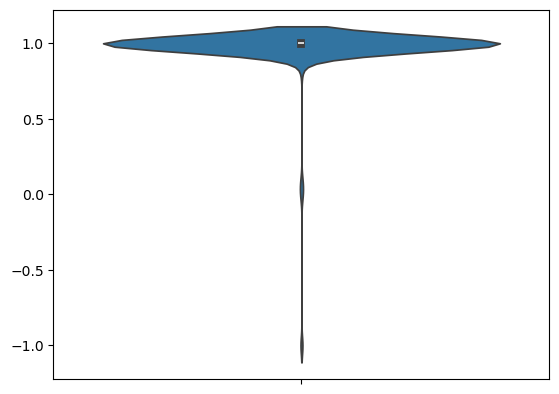

In [72]:
r=[]
for QC in [QC_cre,QC_ct]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

Correlations generally look pretty good. Let's examine the cases where they aren't.

Notably all of the bad ones are from the set of "by cell-type" models.

I'm going to guess these are low-expressing CREs. Let's take a look.

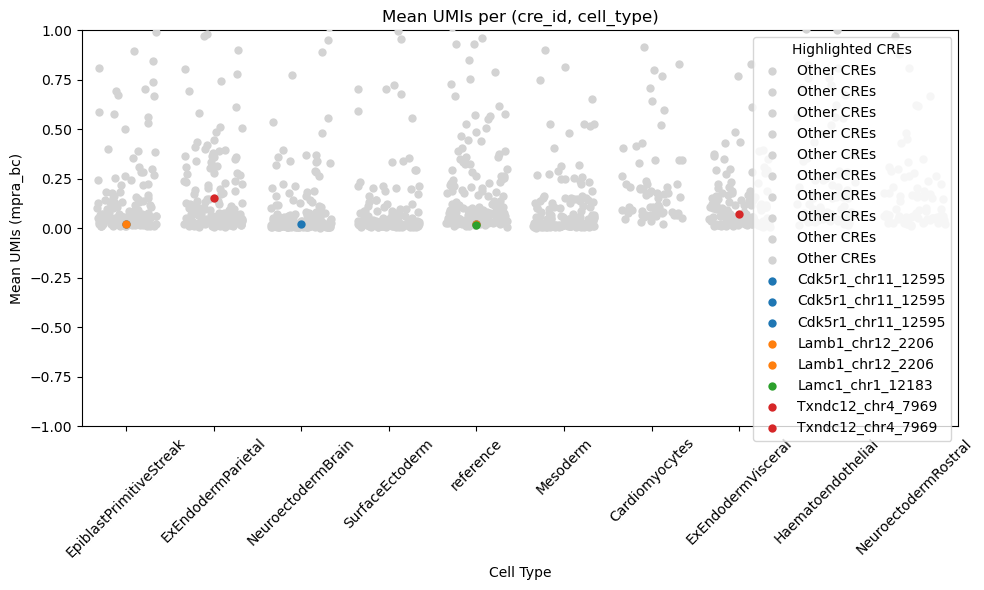

In [94]:
highlighted_cre_ids=["Cdk5r1_chr11_12595","Lamb1_chr12_2206","Lamc1_chr1_12183","Txndc12_chr4_7969"]

grouped = (
    shendure.data
    .groupby(["cre_id", "cell_type"])["umis_mpra_bc"]
    .mean()
    .reset_index()
)

# Split base vs. highlighted
base = grouped[~grouped["cre_id"].isin(highlighted_cre_ids)]
highlighted = grouped[grouped["cre_id"].isin(highlighted_cre_ids)]

# Set up plot
plt.figure(figsize=(10, 6))

# Plot base layer with jitter
sns.stripplot(
    data=base,
    x="cell_type",
    y="umis_mpra_bc",
    color="lightgray",
    jitter=0.35,
    label="Other CREs",
    size=6
)

# Overlay highlighted CREs with jitter and custom color
palette = sns.color_palette("tab10", n_colors=len(highlighted_cre_ids))
for i, cre in enumerate(highlighted_cre_ids):
    sns.stripplot(
        data=highlighted[highlighted["cre_id"] == cre],
        x="cell_type",
        y="umis_mpra_bc",
        color=palette[i],
        jitter=0.35,
        label=cre,
        size=6
    )

# Y-axis and aesthetics
plt.ylim(-1, 1)
plt.xlabel("Cell Type")
plt.ylabel("Mean UMIs (mpra_bc)")
plt.title("Mean UMIs per (cre_id, cell_type)")
plt.xticks(rotation=45)
plt.legend(title="Highlighted CREs")
plt.tight_layout()
plt.show()


In [76]:
QC_cre["Cdk5r1_chr11_12595"]

{'success': True,
 'dat':                                mu  mean(umis_mpra_bc)
 cell_type                                            
 EpiblastPrimitiveStreak  0.049585            0.021552
 NeuroectodermBrain       0.053285            0.023256
 reference                0.055749            0.021467,
 'slope': 0.22477817683836346,
 'intercept': 0.047907093274978184,
 'r_value': 0.07311215649174835,
 'p_value': 0.9534137889876233,
 'std_err': 3.066201564750196}

Let's examine all of them together graphically

# Graphical, CRE models

# Graphical, CT models

In [ ]:
for cell_type in QC:
    sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    plt.title(cell_type)
    plt.show()
    

In [13]:
client.close()